# Testing
## Bevölkerung nach Monat, Stadtquartier, Geschlecht, Altersgruppe und Herkunft, seit 1998
Datum: 08.12.2021

### Importiere die notwendigen Packages

In [1]:
import pandas as pd

import numpy as np
import altair as alt
import matplotlib.pyplot as plt
from datetime import datetime
import datetime
from dateutil.relativedelta import *
import geopandas as gpd
import folium 
import plotly.express as px

import requests
import io


In [2]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [3]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

Definiere Settings. Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen), 

In [4]:
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

### Zeitvariabeln
Bestimme den aktuellst geladenen Monat. Hier ist es der Stand vor 2 Monaten. 
Bestimme noch weitere evt. sinnvolle Zeitvariabeln.

Zum Unterschied zwischen import datetime und from datedtime import datetime, siehe https://stackoverflow.com/questions/15707532/import-datetime-v-s-from-datetime-import-datetime

#### Zuerst die generellen Zeitvariabeln als Strings

In [5]:
#today_date = datetime.date.today()
#date_time = datetime.datetime.strptime(date_time_string, '%Y-%m-%d %H:%M')
now = datetime.date.today()
date_today = now.strftime("%Y-%m-%d")
year_today = now.strftime("%Y")
year_month_today = now.strftime("%Y-%m")
month_today = now.strftime("%Y")
day_today = now.strftime("%d")

date_day_a_week_ago = (datetime.datetime.now() - datetime.timedelta(days=7)).date()
day_a_week_ago = date_day_a_week_ago.strftime('%Y-%m-%d')

#### Die zu testenden Zeitvariabeln als Strings

Hier mal die folgenden:
- `latest_year_month`: Der aktuellste Datenstand sollte ja immer der heutige Monat minus 2 sein.
- `latest_year`: Der aktuellste Datenstand sollte ja immer der heutige Monat minus 2 sein. Hier wird das damalige Jahr angegeben.
- `five_years_ago`: Und damit nicht immer alle Zeitreihen geprüft werden müssen, kann auch das Jahr vor 5 Jahren definiert werden.

In [6]:
#from datetime import datetime, timedelta
#from dateutil.relativedelta import *

latest_year_month = now + relativedelta(months=-2)
latest_year_month = latest_year_month.strftime("%Y-%m")
print(latest_year_month)

latest_year = now + relativedelta(months=-2)
latest_year = latest_year.strftime("%Y")
print(latest_year)

five_years_ago  = now + relativedelta(years=-5)
five_years_ago = five_years_ago.strftime("%Y")
print(five_years_ago)

2024-06
2024
2019


#### Und hier noch die Zeitvariabeln als Integers:
- `aktuellesJahr`
- `aktuellerMonat`: Der gerade jetzt aktuelle Monat
- `selectedMonat`: Der aktuellste Monat in den Daten. In der Regel zwei Monate her.

In [7]:
#now = datetime.now() 
int_times = now.timetuple()

aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2

print(aktuellesJahr, 
      aktuellerMonat,
    'datenstand: ', selectedMonat,
     int_times)


2024 8 datenstand:  6 time.struct_time(tm_year=2024, tm_mon=8, tm_mday=16, tm_hour=0, tm_min=0, tm_sec=0, tm_wday=4, tm_yday=229, tm_isdst=-1)


Berechne die Variable Epoche um später das SAS-Datum in ein Unix-Datum umzuwandeln. Bei SAS beginnt die Epoche am 1.1.1960. Bei Unix am 1.1.1970.
Diese Variable wird beim CSV-Import benötigt.

In [8]:
epoch = datetime.datetime(1960, 1, 1)

In [9]:
epoch

datetime.datetime(1960, 1, 1, 0, 0)

### Setze einige Pfadvariabeln

- Der Packagename ist eigentlich der **Verzeichnisname** unter dem die Daten und Metadaten auf der Dropzone abgelegt werden.
- Definiert wird er bei SASA-Prozessen auf dem **Produkte-Sharepoint ([Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/PersonalViews.aspx?PageView=Personal&ShowWebPart={6087A3E7-8AC8-40BA-8278-DECFACE124FF}))**.
- Der Packagename wird auf CKAN teil der URL, daher ist die exakte Schreibweise wichtig.

Beachte: im Packagename müssen alle Buchstaben **klein** geschrieben werden. Dies weil CKAN aus grossen kleine Buchstaben macht.

**BITTE HIER ANPASSEN**

In [10]:
package_name = "bev_monat_bestand_quartier_geschl_ag_herkunft_od3250"

In [11]:
dataset_name = "BEV325OD3250.csv"

**Statische Pfade in DWH-Dropzones**

In [12]:
dropzone_path_integ = r"\\szh\ssz\applikationen\OGD_Dropzone\INT_DWH"

In [13]:
dropzone_path_prod = r"\\szh\ssz\applikationen\OGD_Dropzone\DWH"

**Statische Pfade CKAN-URLs**

In [14]:
ckan_integ_url ="https://data.integ.stadt-zuerich.ch/dataset/int_dwh_"

In [15]:
ckan_prod_url ="https://data.stadt-zuerich.ch/dataset/"

### Checke die Metadaten auf der CKAN INTEG- oder PROD-Webseite

Offenbar lassen sich aktuell im Markdownteil keine Variabeln ausführen, daher gehen wir wie unten gezeigt vor. Siehe dazu: https://data-dive.com/jupyterlab-markdown-cells-include-variables
Instead of setting the cell to Markdown, create Markdown from withnin a code cell! We can just use python variable replacement syntax to make the text dynamic

In [16]:
from IPython.display import Markdown as md

In [17]:
md(" **1. Dataset auf INTEG-Datakatalog:** Link {} ".format(ckan_integ_url+package_name))

 **1. Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_monat_bestand_quartier_geschl_ag_herkunft_od3250 

In [18]:
md(" **2. Dataset auf PROD-Datakatalog:** Link {} ".format(ckan_prod_url+package_name))

 **2. Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_monat_bestand_quartier_geschl_ag_herkunft_od3250 

### Importiere einen Datensatz 

Definiere zuerst folgende Werte:
1) Kommt der Datensatz von PROD oder INTEG?
2) Beziehst Du den Datensatz direkt ab der DROPZONE oder aus dem INTERNET?

In [19]:
#Die Datasets sind nur zum Testen auf INT-DWH-Dropzone. Wenn der Test vorbei ist, sind sie auf PROD. 
# Über den Status kann man einfach switchen

status = "int"; #prod vs something else
data_source = "dropzone"; #dropzone vs something else
print(status+" - "+ data_source)

int - dropzone


In [20]:
# Filepath
if status == "prod":
    if data_source == "dropzone":
            fp = dropzone_path_prod+"\\"+ package_name +"\\"+dataset_name
            print("fp lautet:"+fp)
    else:
        #fp = r"https://data.stadt-zuerich.ch/dataset/bau_neubau_whg_bausm_rinh_geb_projstatus_quartier_seit2009_od5011/download/BAU501OD5011.csv"
        fp = ckan_prod_url+package_name+'/download/'+dataset_name
        print("fp lautet:"+fp)
else:
    if data_source == "dropzone":
        fp = dropzone_path_integ+"\\"+ package_name +"\\"+dataset_name
        print("fp lautet:"+fp)
    else:
        #fp = r"https://data.stadt-zuerich.ch/dataset/bau_neubau_whg_bausm_rinh_geb_projstatus_quartier_seit2009_od5011/download/BAU501OD5011.csv"
        fp = ckan_integ_url+package_name+'/download/'+dataset_name
        print("fp lautet:"+fp)


fp lautet:\\szh\ssz\applikationen\OGD_Dropzone\INT_DWH\bev_monat_bestand_quartier_geschl_ag_herkunft_od3250\BEV325OD3250.csv


Beachte, wie das SAS Datum (ohne Format) in ein UNIX Datum umgerechnet und als Datumsformat dargestellt wird! Siehe dazu `https://stackoverflow.com/questions/26923564/convert-sas-numeric-to-python-datetime`

In [21]:
# Read the data
if data_source == "dropzone":
    data2betested = pd.read_csv(
        fp
        , sep=','
        ,parse_dates=['StichtagDat']
        #, date_parser=lambda s: epoch + datetime.timedelta(days=int(s))
        ,low_memory=False
    )
    print("dropzone")
else:
    r = requests.get(fp, verify=False)  
    r.encoding = 'utf-8'
    data2betested = pd.read_csv(
        io.StringIO(r.text)
        ,parse_dates=['StichtagDat']
        # KONVERTIERE DAS SAS DATUM IN EIN UNIXDATUM UND FORMATIERE ES
        #, date_parser=lambda s: epoch + datetime.timedelta(days=int(s))
        ,low_memory=False)
    print("web")

data2betested.dtypes
#data2betested.head(2)

dropzone


StichtagDatJahr                      int64
StichtagDatMM                        int64
StichtagDatMonat                    object
StichtagDat                 datetime64[ns]
SexCd                                int64
SexLang                             object
AlterV20ueber80Sort_noDM             int64
AlterV20ueber80Cd_noDM               int64
AlterV20ueber80Kurz_noDM            object
HerkunftCd                           int64
HerkunftLang                        object
KreisCd                              int64
KreisLang                           object
QuarCd                               int64
QuarLang                            object
DatenstandCd                        object
DatenstandLang                      object
AnzBestWir                           int64
dtype: object

In [22]:
data_max_date = str(max(data2betested.StichtagDat).year)
data_min_date = str(min(data2betested.StichtagDat).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1998 und ein Maximumjahr von 2024


Berechne weitere Attribute falls notwendig

### Einfache Datentests

 - 1) Zeige eine kurze Vorschau der importierten Daten
 - 2) Weise die Datentypen aus
 - 3) Zeige die Shape (Umfang) des Datensatzes an

In [23]:
data2betested.sort_values('StichtagDat', ascending=False).head(2).T

,216209,215753
StichtagDatJahr,2024,2024
StichtagDatMM,6,6
StichtagDatMonat,Juni,Juni
StichtagDat,2024-06-30 00:00:00,2024-06-30 00:00:00
SexCd,2,2
SexLang,weiblich,weiblich
AlterV20ueber80Sort_noDM,5,2
AlterV20ueber80Cd_noDM,5,2
AlterV20ueber80Kurz_noDM,80 u. älter,20-39
HerkunftCd,2,1


In [24]:
#data2betested.dtypes
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216210 entries, 0 to 216209
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   StichtagDatJahr           216210 non-null  int64         
 1   StichtagDatMM             216210 non-null  int64         
 2   StichtagDatMonat          216210 non-null  object        
 3   StichtagDat               216210 non-null  datetime64[ns]
 4   SexCd                     216210 non-null  int64         
 5   SexLang                   216210 non-null  object        
 6   AlterV20ueber80Sort_noDM  216210 non-null  int64         
 7   AlterV20ueber80Cd_noDM    216210 non-null  int64         
 8   AlterV20ueber80Kurz_noDM  216210 non-null  object        
 9   HerkunftCd                216210 non-null  int64         
 10  HerkunftLang              216210 non-null  object        
 11  KreisCd                   216210 non-null  int64         
 12  Kr

In [25]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 216,210 rows (observations) and 18 columns (variables).
There seem to be 0 exact duplicates in the data.


#### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [26]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [27]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,StichtagDatJahr,StichtagDatMM,SexCd,AlterV20ueber80Sort_noDM,AlterV20ueber80Cd_noDM,HerkunftCd,KreisCd,QuarCd,AnzBestWir
count,"216,210","216,210","216,210","216,210","216,210","216,210","216,210","216,210","216,210"
mean,"2,011",6,2,3,3,1,6,67,580
std,8,3,1,1,1,0,6,53,623
min,"1,998",1,1,1,1,1,1,11,0
25%,"2,004",3,1,2,2,1,3,33,104
50%,"2,011",6,2,3,3,1,7,71,380
75%,"2,017",9,2,4,4,2,9,92,829
max,"2,024",12,2,5,5,2,99,999,"3,798"


#### Nullwerte und Missings?

Wie viele Nullwerte gibt es im Datensatz?

In [28]:
data2betested.isnull().sum()

StichtagDatJahr             0
StichtagDatMM               0
StichtagDatMonat            0
StichtagDat                 0
SexCd                       0
SexLang                     0
AlterV20ueber80Sort_noDM    0
AlterV20ueber80Cd_noDM      0
AlterV20ueber80Kurz_noDM    0
HerkunftCd                  0
HerkunftLang                0
KreisCd                     0
KreisLang                   0
QuarCd                      0
QuarLang                    0
DatenstandCd                0
DatenstandLang              0
AnzBestWir                  0
dtype: int64

Welches sind die Quartiere ohne Werte bei AnzBestWir?

In [29]:
data2betested[np.isnan(data2betested.AnzBestWir)]

,StichtagDatJahr,StichtagDatMM,StichtagDatMonat,StichtagDat,SexCd,SexLang,AlterV20ueber80Sort_noDM,...,KreisCd,KreisLang,QuarCd,QuarLang,DatenstandCd,DatenstandLang,AnzBestWir


In [30]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,StichtagDatJahr,StichtagDatMM,StichtagDatMonat,StichtagDat,SexCd,SexLang,AlterV20ueber80Sort_noDM,...,KreisCd,KreisLang,QuarCd,QuarLang,DatenstandCd,DatenstandLang,AnzBestWir


In [31]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

Zeige ein Histogramm für jedes numerische Attribut

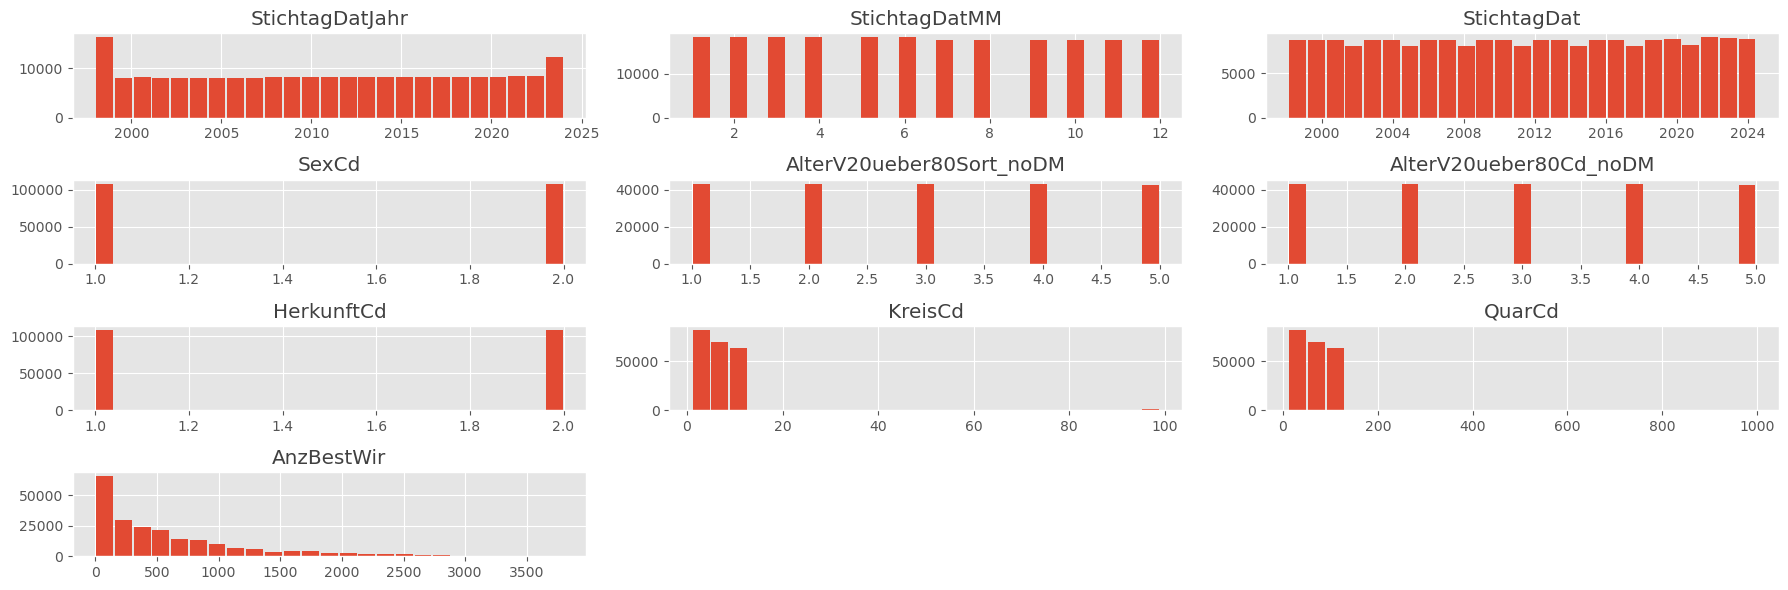

In [32]:
# plot a histogram for each numerical feature
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [33]:
data2betested = data2betested.set_index("StichtagDat")
data2betested = data2betested.sort_index()

In [34]:
#data2betested.info()
data2betested.index.year.unique()

Index([1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,
       2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
      dtype='int32', name='StichtagDat')

### Einfache Visualisierungen zur Plausi

Exploriere die Daten mit Pivottable.JS

In [35]:
#from pivottablejs import pivot_ui

#pivot_ui(data2betested)

### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

In [36]:
data2betested.loc["2024"].head(2)
#data2betested.loc["2021-10-31":"2021-11-30"].head(2)
#data2betested.sort_index()

,StichtagDatJahr,StichtagDatMM,StichtagDatMonat,SexCd,SexLang,AlterV20ueber80Sort_noDM,AlterV20ueber80Cd_noDM,...,KreisCd,KreisLang,QuarCd,QuarLang,DatenstandCd,DatenstandLang,AnzBestWir
StichtagDat,,,,,,,,,,,,,,,
2024-01-31,2024,1,Januar,1,männlich,1,1,...,1,Kreis 1,11,Rathaus,P,Provisorisch,118
2024-01-31,2024,1,Januar,1,männlich,1,1,...,1,Kreis 1,12,Hochschulen,P,Provisorisch,23


### Aggregiere Werte nach Zeitausschnitten

Mit den Funktionen zur Zeit kann einfach zwischen Stunden, Tagen, Monaten, etc. gewechselt und aggregiert werden.
Da die Daten bereits aggregiert nach Monaten sind, macht das hier keinen Sinn.
Untenstehendes also nur als BSP


In [37]:
# first we create the sums per week
weekly_sums = data2betested.resample("W").sum()
# then we generate the weekly means for each quarter
data2betested_sel = data2betested[["SexCd","HerkunftCd","AnzBestWir"]]
quarterly_sums = data2betested_sel.resample("Q").sum()
# for readability we'll revert the values back to integers
quarterly_sums.astype(int).head(1)

C:\Users\sszsim\AppData\Local\Temp\ipykernel_10080\2687936914.py:5: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_sums = data2betested_sel.resample("Q").sum()


,SexCd,HerkunftCd,AnzBestWir
StichtagDat,,,
1998-03-31,3057,3054,1077987


### Visualisierungen nach Zeitausschnitten

In [38]:
data2betested.info()
#data2betested

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 216210 entries, 1998-01-31 to 2024-06-30
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   StichtagDatJahr           216210 non-null  int64 
 1   StichtagDatMM             216210 non-null  int64 
 2   StichtagDatMonat          216210 non-null  object
 3   SexCd                     216210 non-null  int64 
 4   SexLang                   216210 non-null  object
 5   AlterV20ueber80Sort_noDM  216210 non-null  int64 
 6   AlterV20ueber80Cd_noDM    216210 non-null  int64 
 7   AlterV20ueber80Kurz_noDM  216210 non-null  object
 8   HerkunftCd                216210 non-null  int64 
 9   HerkunftLang              216210 non-null  object
 10  KreisCd                   216210 non-null  int64 
 11  KreisLang                 216210 non-null  object
 12  QuarCd                    216210 non-null  int64 
 13  QuarLang                  216210 non-null  

#### Entwicklung Wohnbevölkerung nach Stadtkreis

In [59]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg = data2betested \
    .groupby(['StichtagDat','StichtagDatJahr', 'StichtagDatMM','KreisLang', 'KreisCd']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myAgg.reset_index().sort_values('KreisCd', ascending=True).head(2)

,StichtagDat,StichtagDatJahr,StichtagDatMM,KreisLang,KreisCd,sum_WBev
3569,2019-06-30,2019,6,Kreis 1,1,5822
3600,2001-07-31,2001,7,Kreis 1,1,5764


In [60]:
myTitle="Wohnbevölkerung nach Stadtkreis"

highlight = alt.selection(type='single', on='mouseover',
                          fields=['KreisLang'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myAgg.reset_index().query('sum_WBev>1').sort_values('KreisCd', ascending=True), title=myTitle).encode(
    x=alt.X('StichtagDat', axis=alt.Axis(title='Jahr'))# , axis=alt.Axis(format='%', title='percentage')
    , y=alt.X('sum_WBev', axis=alt.Axis(title='Anz. Personen'))
    , color=alt.Color('KreisLang', legend=alt.Legend(title="Stadtkreise", orient="right"))  
    ,tooltip=['StichtagDat', 'KreisLang', 'sum_WBev']    
)
points = base.mark_circle().encode(
    opacity=alt.value(0.75)
).add_selection(
    highlight
).properties(
    width=900 , height=350
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(0.5), alt.value(4))
).interactive()

lines + points

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning:

'selection' is deprecated.
   Use 'selection_point()' or 'selection_interval()' instead; these functions also include more helpful docstrings.

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\vegalite\v5\api.py:425: AltairDeprecationWarning:

The types 'single' and 'multi' are now
        combined and should be specified using "selection_point()".

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning:

'add_selection' is deprecated. Use 'add_params' instead.

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\core.py:395: FutureWarning:

the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.



alt.LayerChart(...)

#### Entwicklung nach Alter

In [61]:
data2betested.dtypes
data2betested.head(2)

,StichtagDatJahr,StichtagDatMM,StichtagDatMonat,SexCd,SexLang,AlterV20ueber80Sort_noDM,AlterV20ueber80Cd_noDM,...,KreisCd,KreisLang,QuarCd,QuarLang,DatenstandCd,DatenstandLang,AnzBestWir
StichtagDat,,,,,,,,,,,,,,,
1998-01-31,1998,1,Januar,1,männlich,1,1,...,1,Kreis 1,11,Rathaus,V,Veröffentlicht,114
1998-01-31,1998,1,Januar,1,männlich,1,1,...,1,Kreis 1,12,Hochschulen,V,Veröffentlicht,24


In [62]:
#myAgg = data2betested.loc[five_years_ago:latest_year] \
myAgg = data2betested.loc["1993":latest_year] \
    .groupby(['StichtagDat','StichtagDatJahr', 'StichtagDatMM', 'AlterV20ueber80Kurz_noDM']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myAgg.reset_index().head(2)

,StichtagDat,StichtagDatJahr,StichtagDatMM,AlterV20ueber80Kurz_noDM,sum_WBev
0,2023-11-30,2023,11,20-39,165265
1,2023-10-31,2023,10,20-39,165243


In [63]:
myTitle="Wohnbevölkerung nach Altersgruppen"
highlight = alt.selection(type='single', on='mouseover',
                          fields=['AlterV20ueber80Kurz_noDM'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myAgg.reset_index().query('sum_WBev>100'), title=myTitle).encode(
    x=alt.X('StichtagDat', axis=alt.Axis(title='Jahr'))# , axis=alt.Axis(format='%', title='percentage')
    , y=alt.X('sum_WBev', axis=alt.Axis(title='Anz. Personen'))
    , color=alt.Color('AlterV20ueber80Kurz_noDM', legend=alt.Legend(title="Altersgruppen"))  
    ,tooltip=['StichtagDat', 'AlterV20ueber80Kurz_noDM', 'sum_WBev']    
)
points = base.mark_circle().encode(
    opacity=alt.value(0.75)
).add_selection(
    highlight
).properties(
    width=900 , height=350
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(0.5), alt.value(4))
).interactive()

lines + points

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning:

'selection' is deprecated.
   Use 'selection_point()' or 'selection_interval()' instead; these functions also include more helpful docstrings.

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\vegalite\v5\api.py:425: AltairDeprecationWarning:

The types 'single' and 'multi' are now
        combined and should be specified using "selection_point()".

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning:

'add_selection' is deprecated. Use 'add_params' instead.

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\core.py:395: FutureWarning:

the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.



alt.LayerChart(...)

#### Entwicklung nach Heimat

In [44]:
#myAgg = data2betested.loc["2008-11":"2021-11"] \
myAgg = data2betested.loc[five_years_ago:latest_year]  \
    .groupby(['StichtagDat','StichtagDatJahr', 'StichtagDatMM', 'HerkunftLang']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myAgg.reset_index().head(2)

,StichtagDat,StichtagDatJahr,StichtagDatMM,HerkunftLang,sum_WBev
0,2024-06-30,2024,6,Schweizer*in,297153
1,2024-05-31,2024,5,Schweizer*in,297012


In [64]:
myTitle="Wohnbevölkerung nach Herkunft"
highlight = alt.selection(type='single', on='mouseover',
                          fields=['HerkunftLang'], nearest=True)
#x='date:StichtagDatJahr',
base = alt.Chart(myAgg.reset_index().query('sum_WBev>100'), title=myTitle).encode(
    x=alt.X('StichtagDat', axis=alt.Axis(title='Jahr'))# , axis=alt.Axis(format='%', title='percentage')
    , y=alt.X('sum_WBev', axis=alt.Axis(title='Anz. Personen'))
    , color=alt.Color('HerkunftLang', legend=alt.Legend(title="Herkunft"))  
    ,tooltip=['StichtagDat', 'HerkunftLang', 'sum_WBev']    
)
points = base.mark_circle().encode(
    opacity=alt.value(0.75)
).add_selection(
    highlight
).properties(
    width=900 , height=350
)
lines = base.mark_line().encode(
    size=alt.condition(~highlight, alt.value(0.5), alt.value(4))
).interactive()

lines + points    


c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning:

'selection' is deprecated.
   Use 'selection_point()' or 'selection_interval()' instead; these functions also include more helpful docstrings.

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\vegalite\v5\api.py:425: AltairDeprecationWarning:

The types 'single' and 'multi' are now
        combined and should be specified using "selection_point()".

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\deprecation.py:65: AltairDeprecationWarning:

'add_selection' is deprecated. Use 'add_params' instead.

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\altair\utils\core.py:395: FutureWarning:

the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.



ValueError: Unable to determine data type for the field "HerkunftLang"; verify that the field name is not misspelled. If you are referencing a field from a transform, also confirm that the data type is specified correctly.

alt.LayerChart(...)

In [46]:
data2betested.dtypes

StichtagDatJahr              int64
StichtagDatMM                int64
StichtagDatMonat            object
SexCd                        int64
SexLang                     object
AlterV20ueber80Sort_noDM     int64
AlterV20ueber80Cd_noDM       int64
AlterV20ueber80Kurz_noDM    object
HerkunftCd                   int64
HerkunftLang                object
KreisCd                      int64
KreisLang                   object
QuarCd                       int64
QuarLang                    object
DatenstandCd                object
DatenstandLang              object
AnzBestWir                   int64
dtype: object

### Daten in interaktiver Treemap zeigen
Dazu gibt es eine sehr nützliche Webseite https://plotly.com/python/treemaps/
Zu Farbskalen, siehe: https://plotly.com/python/builtin-colorscales/

#### Aktueller Bestand der WBev nach Stadtkreis, Quartier, Alter und Herkunft

In [65]:
myTreemapAgg = data2betested.loc["2020":data_max_date]   \
    .groupby(['StichtagDat','StichtagDatJahr', 'StichtagDatMM', 'KreisLang','QuarLang','HerkunftLang', 'AlterV20ueber80Kurz_noDM' ]) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDat', ascending=False) 

myTreemapAgg.reset_index().head(4)

#.query("KreisLang ='Unbekannt'")\


,StichtagDat,StichtagDatJahr,StichtagDatMM,KreisLang,QuarLang,HerkunftLang,AlterV20ueber80Kurz_noDM,sum_WBev
0,2024-06-30,2024,6,Unbekannt,Unbekannt,Schweizer*in,40-59,1
1,2024-06-30,2024,6,Kreis 12,Schwamendingen-Mitte,Schweizer*in,20-39,1975
2,2024-06-30,2024,6,Kreis 12,Saatlen,Schweizer*in,60-79,931
3,2024-06-30,2024,6,Kreis 12,Saatlen,Schweizer*in,80 u. älter,205


In [66]:
fig = px.treemap(myTreemapAgg.reset_index(), path=[px.Constant("WBev nach Stadtkreis, Quartier, Alter und Herkunft"), 'KreisLang','QuarLang','HerkunftLang', 'AlterV20ueber80Kurz_noDM']
                 , values='sum_WBev'
                 , color='sum_WBev'
                 ## bei discrete scales (bei Klassen und Strings):                 
                 #, color_discrete_map={'(?)':'lightgrey','EVP':'gold', 'SP':'#FF3030', 'PdA':'#EE3B3B', 'Grüne':'#A2CD5A','GLP':'#CAFF70','Die Mitte':'orange','FDP':'#104E8B','AL':'deeppink','SVP':'forestgreen', 'FL ZÜRI':'#8B864E','Volt':'#lightblue' }                
                 ## bei continuous scales (bei Zahlenwerten):
                , color_continuous_scale='Blues'
                #, color_continuous_midpoint=np.average(df['AnzBestWir'], weights=df['AnzBestWir'])  
                 #,height=400
                 #,width=1500                 
                )
fig.update_traces(root_color="grey")
fig.update_layout(margin = dict(t=50, l=25, r=250, b=25))
fig.show()

#### Aktueller Bestand der WBev nach Stadtkreis, Alter und Herkunft

In [49]:
print(latest_year_month)

2024-06


In [67]:
myTreemapAgg = data2betested.loc[latest_year_month]  \
    .groupby(['StichtagDat','StichtagDatJahr', 'StichtagDatMM', 'KreisLang','HerkunftLang', 'AlterV20ueber80Kurz_noDM' ]) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myTreemapAgg.reset_index().head(2)

,StichtagDat,StichtagDatJahr,StichtagDatMM,KreisLang,HerkunftLang,AlterV20ueber80Kurz_noDM,sum_WBev
0,2024-06-30,2024,6,Kreis 11,Ausländer*in,20-39,15213
1,2024-06-30,2024,6,Kreis 11,Schweizer*in,20-39,15118


In [68]:
fig = px.treemap(myTreemapAgg.reset_index()
                 , path=[px.Constant("WBev nach Alter, Stadtkreis und Herkunft"), 'AlterV20ueber80Kurz_noDM','KreisLang','HerkunftLang']
                 , values='sum_WBev'
                 , color='sum_WBev'
                 ## bei discrete scales (bei Klassen und Strings):                 
                 #, color_discrete_map={'(?)':'lightgrey','EVP':'gold', 'SP':'#FF3030', 'PdA':'#EE3B3B', 'Grüne':'#A2CD5A','GLP':'#CAFF70','Die Mitte':'orange','FDP':'#104E8B','AL':'deeppink','SVP':'forestgreen', 'FL ZÜRI':'#8B864E','Volt':'#lightblue' }                
                 ## bei continuous scales (bei Zahlenwerten):
                , color_continuous_scale='PuBuGn'
                #, color_continuous_midpoint=np.average(df['AnzBestWir'], weights=df['AnzBestWir']) 
                 #,height=400
                 #,width=1500
                )
fig.update_traces(root_color="grey")
fig.update_layout(margin = dict(t=50, l=25, r=250, b=25))#, title="WBev nach Alter, Stadtkreis und Herkunft")
fig.show()

Liniendiagramm 
[Link zur Doku](https://altair-viz.github.io/gallery/multiline_highlight.html)

### Test: Choroplethenkarte
Importiere die Geodaten als GeoJSON

In [69]:
# Read abt. Geopandas https://geopandas.org/docs/user_guide/io.html
# Wenn die Daten lokal agelegt sind, dann kannst Du folgendes machen:
##input_stadtquartiere = r"//szh.loc/ssz/data/GIS/Daten/Vektor/_aktuell/stzh.adm_statistische_quartiere_map.json"
##df_stadtquartiere = gpd.read_file(input_stadtquartiere)
##df_stadtquartiere.head(2)
#df_stadtkreise.dtypes

geojson_url = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Quartiere?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_statistische_quartiere_map"
df_adm_statistische_quartiere_map = gpd.read_file(geojson_url)

df_adm_statistische_quartiere_map.head(5)


,id,kname,knr,objectid,objid,qname,qnr,geometry
0,adm_statistische_quartiere_map.1,Kreis 7,7,1,34,Hirslanden,73,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ..."
1,adm_statistische_quartiere_map.2,Kreis 8,8,2,33,Weinegg,83,"POLYGON ((8.55670 47.36405, 8.55672 47.36403, ..."
2,adm_statistische_quartiere_map.3,Kreis 8,8,3,32,Mühlebach,82,"POLYGON ((8.55423 47.36456, 8.55426 47.36452, ..."
3,adm_statistische_quartiere_map.4,Kreis 8,8,4,31,Seefeld,81,"POLYGON ((8.54795 47.36500, 8.54805 47.36489, ..."
4,adm_statistische_quartiere_map.7,Kreis 4,4,7,16,Werd,41,"POLYGON ((8.53300 47.37394, 8.53299 47.37392, ..."


Joine die importierten statistischen Daten des aktuellen Jahres zum Geodatensatz:

*Siehe dazu Doku zu [Geopandas](https://geopandas.org/docs/user_guide/mergingdata.html)*

In [70]:
akt_wbev_quart = data2betested.loc[latest_year_month].groupby(
    ['StichtagDatJahr','StichtagDatMM','QuarCd','QuarLang']
).agg(
    {'AnzBestWir':'sum'}
)
akt_wbev_quart.head()


AnzBestWir
StichtagDatJahr StichtagDatMM QuarCd QuarLang               
2024            6             11     Rathaus            3339
                              12     Hochschulen         692
                              13     Lindenhof          1050
                              14     City                807
                              21     Wollishofen       21541

In [71]:
# Rename attribute stznr to StatZoneSort, so the IDs have the same name
stadtquartiere_shapes = df_adm_statistische_quartiere_map[['geometry', 'qnr', 'qname', 'knr']].rename(columns={'qnr': 'QuarCd'})

# Merge with `merge` method on shared variable (stznr und StatZoneSort):
stadtquartiere_shapes_joined = stadtquartiere_shapes.merge(akt_wbev_quart, on='QuarCd')

stadtquartiere_shapes_joined.head(2)


,geometry,QuarCd,qname,knr,AnzBestWir
0,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ...",73,Hirslanden,7,7703
1,"POLYGON ((8.55670 47.36405, 8.55672 47.36403, ...",83,Weinegg,8,5638


c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\mapclassify\classifiers.py:1860: UserWarning:

Numba not installed. Using slow pure python version.



<Axes: >

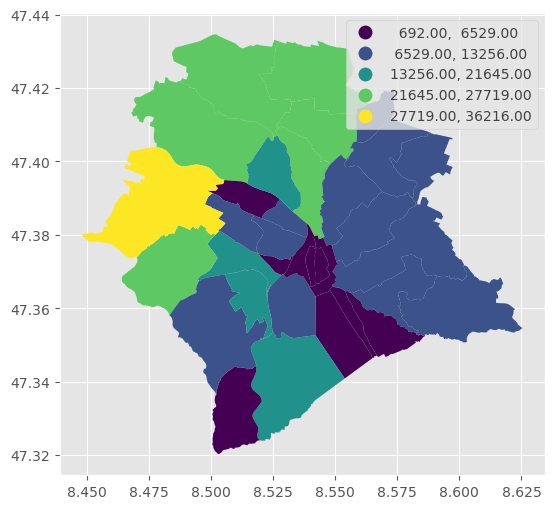

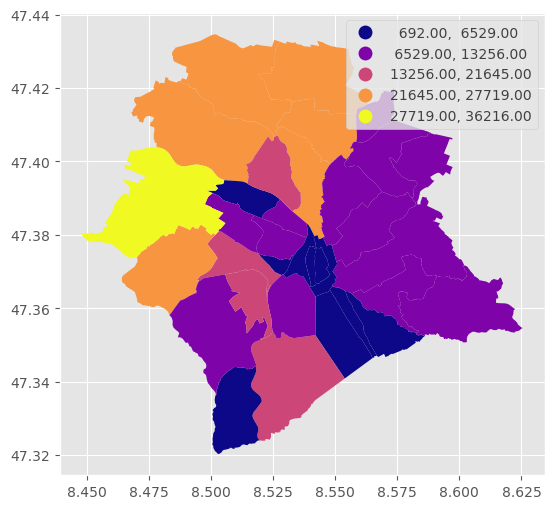

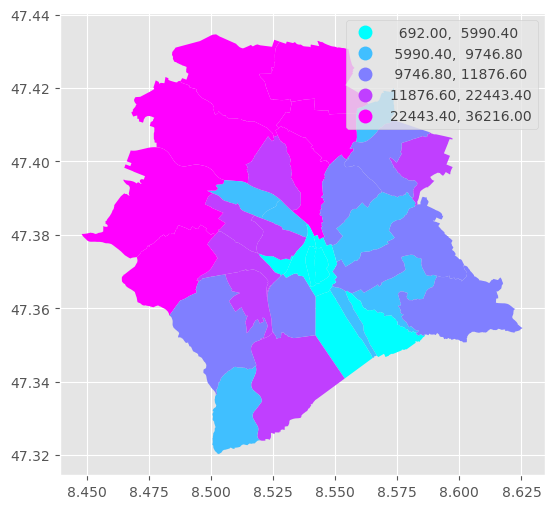

In [72]:
# Plot by StatQuartiere
# Weitere Schemes: scheme='quantiles', scheme='fisherjenks', scheme='natural_breaks',

stadtquartiere_shapes_joined.plot(column='AnzBestWir', cmap='viridis', scheme='natural_breaks', legend=True )
#scheme werte: https://matplotlib.org/2.0.2/users/colormaps.html

stadtquartiere_shapes_joined.plot(column='AnzBestWir', cmap='plasma', scheme='fisherjenks', legend=True )
#scheme werte: https://matplotlib.org/2.0.2/users/colormaps.html
stadtquartiere_shapes_joined.plot(column='AnzBestWir', cmap='cool', scheme='quantiles', legend=True )
#scheme werte: https://matplotlib.org/2.0.2/users/colormaps.html

#
#Neuere Gallerie: https://matplotlib.org/stable/gallery/index.html

Noch zu prüfen, folgendes schöne Beispiel: https://docs.bokeh.org/en/latest/docs/user_guide/interaction/legends.html

Konkrete Beispiele von Bookeh in Jupyter NB: https://docs.bokeh.org/en/latest/docs/user_guide/jupyter.html

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](http://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/EditForm.aspx?ID=157&Source=%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs)**